In [2]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load the dataset
df = pd.read_csv("/content/Dataset .csv")  # Replace with your correct path
df.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [6]:
# Dataset shape
print("Shape of dataset:", df.shape)

# Data types and null values
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape of dataset: (9551, 21)

Data Types:
 Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object

Missing Values:
 Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines           

In [7]:
# Fill missing 'Cuisines' with "Unknown"
df['Cuisines'].fillna("Unknown", inplace=True)


<ipython-input-7-9e30e2f9c4c6>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cuisines'].fillna("Unknown", inplace=True)


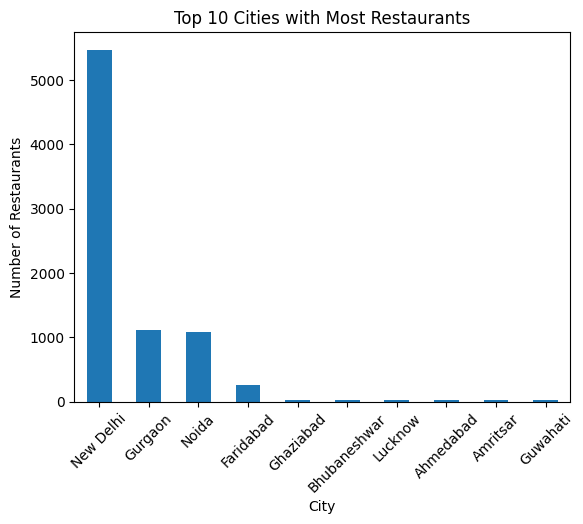

In [8]:
top_cities = df['City'].value_counts().head(10)
top_cities.plot(kind='bar', title='Top 10 Cities with Most Restaurants')
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()


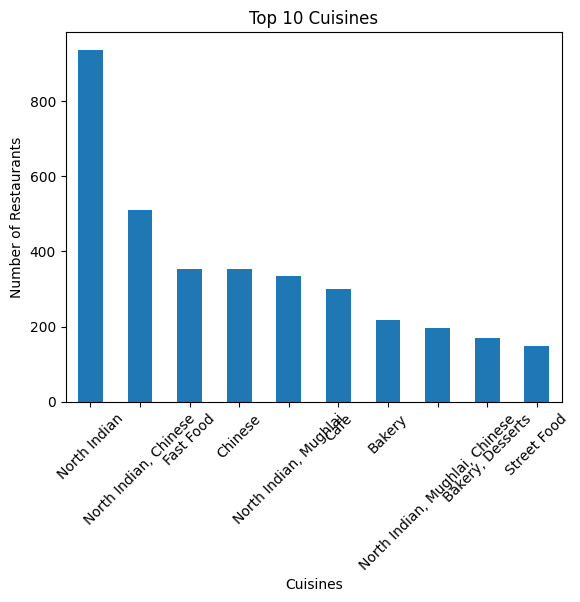

In [9]:
top_cuisines = df['Cuisines'].value_counts().head(10)
top_cuisines.plot(kind='bar', title='Top 10 Cuisines')
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()


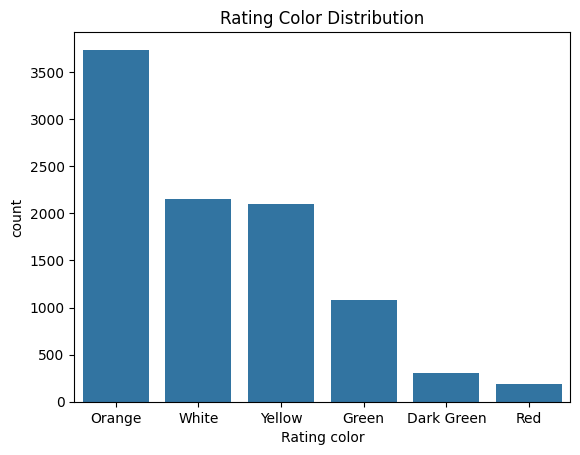

In [10]:
sns.countplot(data=df, x='Rating color', order=df['Rating color'].value_counts().index)
plt.title("Rating Color Distribution")
plt.show()


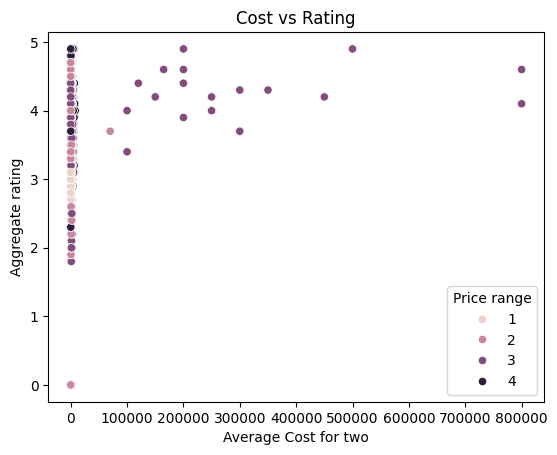

In [11]:
sns.scatterplot(data=df, x='Average Cost for two', y='Aggregate rating', hue='Price range')
plt.title('Cost vs Rating')
plt.show()


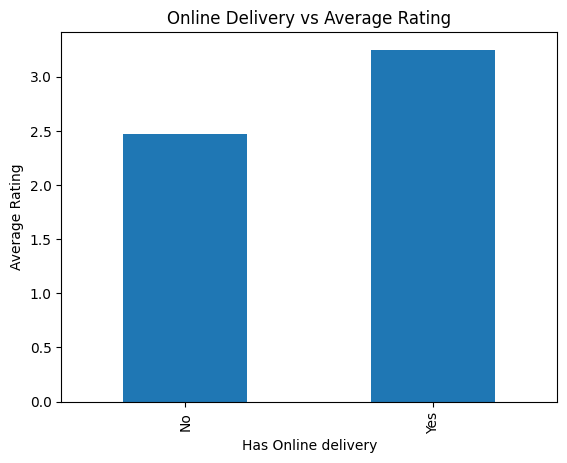

In [12]:
online_vs_rating = df.groupby('Has Online delivery')['Aggregate rating'].mean()
online_vs_rating.plot(kind='bar', title='Online Delivery vs Average Rating')
plt.ylabel("Average Rating")
plt.show()


In [13]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages('restaurant_analysis.pdf') as pdf:
    # Top Cities
    top_cities.plot(kind='bar', title='Top 10 Cities with Most Restaurants')
    plt.xticks(rotation=45)
    pdf.savefig()
    plt.close()

    # Top Cuisines
    top_cuisines.plot(kind='bar', title='Top 10 Cuisines')
    plt.xticks(rotation=45)
    pdf.savefig()
    plt.close()
